<a href="https://colab.research.google.com/github/KS6Git/Python_EDA_Raja/blob/main/Decision_Tree_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##DECISION TREE ASSIGNMENT
Problem Statement:
This assignment aims to utilize Decision Tree algorithms to analyze given datasets, extracting
meaningful insights and predicting outcomes based on the decision rules learned from the data.
By exploring the datasets and employing Decision Tree techniques, students are expected to
build predictive models and interpret the decision rules to derive valuable insights.

##Links to Datasets for the Assignment:
- Obesity Classification Dataset
[https://www.kaggle.com/datasets/sujithmandala/obesity-classification-dataset]
- Email Spam Classification Dataset
[https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv]
- Heart Attack Analysis & Prediction Dataset
[https://www.kaggle.com/datasets/rashikrahmanpritom/heart-attack-analysis-prediction-dataset]

##1. Importing necesary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

##2. Loading the Dataset: Obesity Classification

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Raja_Python_Programming/Decision_Tree/Obesity Classification.csv')

##3. Summarising the Dataset

In [3]:
df


,ID,Age,Gender,Height,Weight,BMI,Label
0,1,25,Male,175,80,25.3,Normal Weight
1,2,30,Female,160,60,22.5,Normal Weight
2,3,35,Male,180,90,27.3,Overweight
3,4,40,Female,150,50,20.0,Underweight
4,5,45,Male,190,100,31.2,Obese
...,...,...,...,...,...,...,...
103,106,11,Male,175,10,3.9,Underweight
104,107,16,Female,160,10,3.9,Underweight
105,108,21,Male,180,15,5.6,Underweight
106,109,26,Female,150,15,5.6,Underweight


In [5]:
df.head()

,ID,Age,Gender,Height,Weight,BMI,Label
0,1,25,Male,175,80,25.3,Normal Weight
1,2,30,Female,160,60,22.5,Normal Weight
2,3,35,Male,180,90,27.3,Overweight
3,4,40,Female,150,50,20.0,Underweight
4,5,45,Male,190,100,31.2,Obese


In [4]:
df.keys()

Index(['ID', 'Age', 'Gender', 'Height', 'Weight', 'BMI', 'Label'], dtype='object')

In [7]:
df.ID

,ID
0,1
1,2
2,3
3,4
4,5
...,...
103,106
104,107
105,108
106,109


In [5]:
pd.DataFrame(df, columns = df.keys())

,ID,Age,Gender,Height,Weight,BMI,Label
0,1,25,Male,175,80,25.3,Normal Weight
1,2,30,Female,160,60,22.5,Normal Weight
2,3,35,Male,180,90,27.3,Overweight
3,4,40,Female,150,50,20.0,Underweight
4,5,45,Male,190,100,31.2,Obese
...,...,...,...,...,...,...,...
103,106,11,Male,175,10,3.9,Underweight
104,107,16,Female,160,10,3.9,Underweight
105,108,21,Male,180,15,5.6,Underweight
106,109,26,Female,150,15,5.6,Underweight


In [16]:
df.describe()


,ID,Age,Height,Weight,BMI
count,108.000000,108.000000,108.000000,108.000000,108.000000
mean,56.046296,46.555556,166.574074,59.490741,20.549074
std,31.917939,24.720620,27.873615,28.856233,7.583818
min,1.000000,11.000000,120.000000,10.000000,3.900000
25%,28.750000,27.000000,140.000000,35.000000,16.700000
50%,56.500000,42.500000,175.000000,55.000000,21.200000
75%,83.250000,59.250000,190.000000,85.000000,26.100000
max,110.000000,112.000000,210.000000,120.000000,37.200000


In [17]:
df.dtypes

,0
ID,int64
Age,int64
Gender,object
Height,int64
Weight,int64
BMI,float64
Label,object


In [7]:
#Converting the Male and Femail to 1 & 0

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df

,ID,Age,Gender,Height,Weight,BMI,Label
0,1,25,1,175,80,25.3,Normal Weight
1,2,30,0,160,60,22.5,Normal Weight
2,3,35,1,180,90,27.3,Overweight
3,4,40,0,150,50,20.0,Underweight
4,5,45,1,190,100,31.2,Obese
...,...,...,...,...,...,...,...
103,106,11,1,175,10,3.9,Underweight
104,107,16,0,160,10,3.9,Underweight
105,108,21,1,180,15,5.6,Underweight
106,109,26,0,150,15,5.6,Underweight


In [8]:
# to inverse the conversion:
df['Gender'] = le.inverse_transform(df['Gender'])

In [9]:
df

,ID,Age,Gender,Height,Weight,BMI,Label
0,1,25,Male,175,80,25.3,Normal Weight
1,2,30,Female,160,60,22.5,Normal Weight
2,3,35,Male,180,90,27.3,Overweight
3,4,40,Female,150,50,20.0,Underweight
4,5,45,Male,190,100,31.2,Obese
...,...,...,...,...,...,...,...
103,106,11,Male,175,10,3.9,Underweight
104,107,16,Female,160,10,3.9,Underweight
105,108,21,Male,180,15,5.6,Underweight
106,109,26,Female,150,15,5.6,Underweight


In [10]:
# Drop labels

df.drop(labels='ID', axis=1, inplace=True)

In [11]:
df

,Age,Gender,Height,Weight,BMI,Label
0,25,Male,175,80,25.3,Normal Weight
1,30,Female,160,60,22.5,Normal Weight
2,35,Male,180,90,27.3,Overweight
3,40,Female,150,50,20.0,Underweight
4,45,Male,190,100,31.2,Obese
...,...,...,...,...,...,...
103,11,Male,175,10,3.9,Underweight
104,16,Female,160,10,3.9,Underweight
105,21,Male,180,15,5.6,Underweight
106,26,Female,150,15,5.6,Underweight


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     108 non-null    int64  
 1   Gender  108 non-null    object 
 2   Height  108 non-null    int64  
 3   Weight  108 non-null    int64  
 4   BMI     108 non-null    float64
 5   Label   108 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 5.2+ KB


In [13]:
# again convert
df['Gender'] = le.fit_transform(df['Gender'])
df

,Age,Gender,Height,Weight,BMI,Label
0,25,1,175,80,25.3,Normal Weight
1,30,0,160,60,22.5,Normal Weight
2,35,1,180,90,27.3,Overweight
3,40,0,150,50,20.0,Underweight
4,45,1,190,100,31.2,Obese
...,...,...,...,...,...,...
103,11,1,175,10,3.9,Underweight
104,16,0,160,10,3.9,Underweight
105,21,1,180,15,5.6,Underweight
106,26,0,150,15,5.6,Underweight


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     108 non-null    int64  
 1   Gender  108 non-null    int64  
 2   Height  108 non-null    int64  
 3   Weight  108 non-null    int64  
 4   BMI     108 non-null    float64
 5   Label   108 non-null    object 
dtypes: float64(1), int64(4), object(1)
memory usage: 5.2+ KB


##4. Segregating the dataset into Input and Output

In [15]:
# Separating the features Input- (X) and Output, target- (y)
X = df.drop('Label', axis=1)
y = df['Label']

##5. Splitting given data to train and test
     The y (target) contains the Label column only
     The X (input) contains all other features
     Ratio of sizing = 80:20
  

In [17]:
# Split the dataset in ttraining and testing sets
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [18]:
X_train.shape

(86, 5)

In [19]:
X_test.shape, y_train.shape, y_train.shape, y_test.shape

((22, 5), (86,), (86,), (22,))

##6. Working on the Decision Tree
**Finding the optimal depth**

In [20]:
accuracy=[]
for i in range(1, 11):      # print 1-10
  print("depth : ", i)
  model=DecisionTreeClassifier(max_depth=i)
  model.fit(X_train, y_train) # training
  y_pred=model.predict(X_test) # testing
  print("accuracy : ", accuracy_score(y_test, y_pred))
  accuracy.append(accuracy_score(y_test, y_pred))

depth :  1
accuracy :  0.6363636363636364
depth :  2
accuracy :  0.7272727272727273
depth :  3
accuracy :  0.9090909090909091
depth :  4
accuracy :  0.9090909090909091
depth :  5
accuracy :  1.0
depth :  6
accuracy :  1.0
depth :  7
accuracy :  1.0
depth :  8
accuracy :  1.0
depth :  9
accuracy :  1.0
depth :  10
accuracy :  1.0


In [21]:
accuracy

[0.6363636363636364,
 0.7272727272727273,
 0.9090909090909091,
 0.9090909090909091,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0]

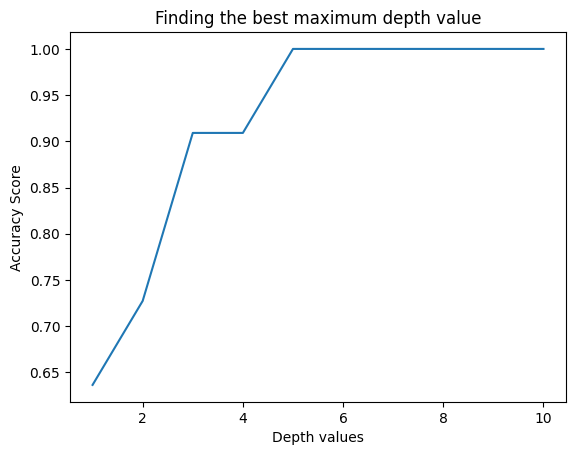

In [23]:
plt.plot(range(1,11), accuracy)

plt.title("Finding the best maximum depth value")
plt.xlabel("Depth values")
plt.ylabel("Accuracy Score")
plt.show()

### **Based on the abv visualisation, the max depth = 5**

##7. Loading the Model

In [24]:
model = DecisionTreeClassifier(max_depth=5, criterion='entropy')


In [25]:
model

DecisionTreeClassifier(criterion='entropy', max_depth=5)

##8. Train the Model

In [26]:
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5)

**Shows max depth = 5**

##9. Test the Model

In [28]:
y_pred = model.predict(X_test)

In [29]:
print(y_pred)

['Normal Weight' 'Normal Weight' 'Obese' 'Underweight' 'Normal Weight'
 'Overweight' 'Normal Weight' 'Overweight' 'Underweight' 'Underweight'
 'Underweight' 'Underweight' 'Normal Weight' 'Underweight' 'Obese'
 'Underweight' 'Obese' 'Overweight' 'Underweight' 'Overweight'
 'Normal Weight' 'Obese']


In [30]:
y_pred

array(['Normal Weight', 'Normal Weight', 'Obese', 'Underweight',
       'Normal Weight', 'Overweight', 'Normal Weight', 'Overweight',
       'Underweight', 'Underweight', 'Underweight', 'Underweight',
       'Normal Weight', 'Underweight', 'Obese', 'Underweight', 'Obese',
       'Overweight', 'Underweight', 'Overweight', 'Normal Weight',
       'Obese'], dtype=object)

##10. Calculating the Accuracy

In [31]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

1.0

##11. Predicting the real world result

In [37]:
X_test

,Age,Gender,Height,Weight,BMI
77,60,0,120,70,23.4
10,18,1,175,70,23.4
4,45,1,190,100,31.2
83,13,1,175,25,10.0
62,36,1,190,75,24.2
67,61,0,120,75,25.0
30,24,0,160,55,21.2
45,52,0,130,75,25.0
95,22,1,180,20,8.3
11,23,0,160,50,20.0


In [27]:
df.keys()

Index(['ID', 'Age', 'Gender', 'Height', 'Weight', 'BMI', 'Label'], dtype='object')

In [64]:
df['Label']

,Label
0,Normal Weight
1,Normal Weight
2,Overweight
3,Underweight
4,Obese
...,...
103,Underweight
104,Underweight
105,Underweight
106,Underweight


In [32]:
new_person = pd.DataFrame({
    'Age':[66],
    'Gender':[1], # male
    'Height':[183],
    'Weight':[93],
    'BMI':[23]
})

**Make the Prediction**

In [33]:
prediction = model.predict(new_person)

In [44]:
print(prediction)

['Normal Weight']


**Get Probability**

In [35]:
model.predict_proba(new_person)

array([[1., 0., 0., 0.]])